# EDA
(Datos Originales NFL)
En este notebook se realizará un acercamiento a la información para definir el camino hacia el desarrollo del proyecto.

## Requisitos para extraer datos

In [2]:
import gspread

from google.colab import auth
from google.colab import drive
from google.auth import default

auth.authenticate_user()
drive.mount('/content/gdrive')
creds, _ = default()
gc = gspread.authorize(creds)

# path
%cd /content/gdrive/MyDrive/'NFL Big Data Bowl 2025'/

Mounted at /content/gdrive
/content/gdrive/MyDrive/NFL Big Data Bowl 2025


## Imports

In [3]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import scipy.spatial as ss
import seaborn as sns
import warnings

## Configuration

In [4]:
warnings.filterwarnings("ignore")

## Constants

In [ ]:
# nb_tracks = -1
nb_tracks = 1

## Functions

In [ ]:
def get_path(*args):
  ## Function to get the path
  path = os.path.join(*args)
  return path

def df_report(df):
  shape = df.shape
  info = df.info()
  df.describe()
  return shape, info, df.describe()

## Paths


In [ ]:
BASE_PATH = os.path.join(os.getcwd())
DATA_PATH = get_path(BASE_PATH, "data")
ORIGINAL_DATA_PATH = get_path(DATA_PATH, "original")
GAMES_PATH = get_path(ORIGINAL_DATA_PATH, "games.csv")
PLAYERS_PATH = get_path(ORIGINAL_DATA_PATH, "players.csv")
PLAYS_PATH = get_path(ORIGINAL_DATA_PATH, "plays.csv")
PLAYER_PLAY_PATH = get_path(ORIGINAL_DATA_PATH, "player_play.csv")
TRACKING_PATH = get_path(ORIGINAL_DATA_PATH, "tracking")

## Read Data

In [ ]:
games_df = pd.read_csv(GAMES_PATH)
players_df = pd.read_csv(PLAYERS_PATH)
play_df = pd.read_csv(PLAYS_PATH)
players_play_df = pd.read_csv(PLAYER_PLAY_PATH)

tracking_df = pd.concat([
    pd.read_csv(get_path(TRACKING_PATH, f))for f in os.listdir(TRACKING_PATH)[: nb_tracks]
])

## Data Analysis

### Games

In [ ]:
df_report(games_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   gameId             136 non-null    int64 
 1   season             136 non-null    int64 
 2   week               136 non-null    int64 
 3   gameDate           136 non-null    object
 4   gameTimeEastern    136 non-null    object
 5   homeTeamAbbr       136 non-null    object
 6   visitorTeamAbbr    136 non-null    object
 7   homeFinalScore     136 non-null    int64 
 8   visitorFinalScore  136 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 9.7+ KB


((136, 9),
 None,
              gameId  season        week  homeFinalScore  visitorFinalScore
 count  1.360000e+02   136.0  136.000000      136.000000         136.000000
 mean   2.022099e+09  2022.0    4.845588       22.669118          20.948529
 std    5.996614e+03     0.0    2.567254        8.659874           9.731446
 min    2.022091e+09  2022.0    1.000000        3.000000           0.000000
 25%    2.022093e+09  2022.0    3.000000       17.000000          14.750000
 50%    2.022101e+09  2022.0    5.000000       22.500000          20.000000
 75%    2.022102e+09  2022.0    7.000000       27.000000          27.000000
 max    2.022111e+09  2022.0    9.000000       49.000000          48.000000)

In [ ]:
games_df.gameDate = pd.to_datetime(games_df.gameDate)

In [ ]:
# Solo se está hablando de una temporada: 2022
games_df.season.value_counts()

,count
season,
2022,136


In [ ]:
games_df.gameId.nunique() # son juegos únicos

136

In [ ]:
games_df.week.value_counts()

,count
week,
1,16
2,16
3,16
4,16
5,16
8,15
6,14
7,14
9,13


<Axes: ylabel='TeamAbbr'>

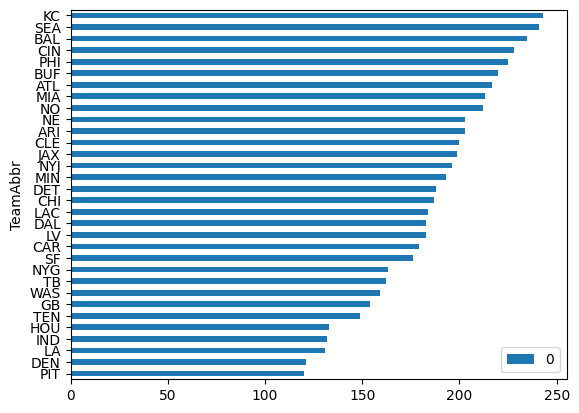

In [ ]:
team_total_scores = (games_df.groupby("homeTeamAbbr").homeFinalScore.sum() + games_df.groupby("visitorTeamAbbr").visitorFinalScore.sum()).sort_values(ascending=True).reset_index().rename(columns={'homeTeamAbbr': 'TeamAbbr'}).set_index('TeamAbbr')
team_total_scores.plot(kind='barh')

In [ ]:
team_resume = pd.concat(
    [games_df.homeTeamAbbr.value_counts().rename("times_home"),
     games_df.visitorTeamAbbr.value_counts().rename("times_visitor"),
     team_total_scores],
    axis=1
).rename(columns={0: 'TotalScore'})

<Axes: xlabel='times_visitor', ylabel='TotalScore'>

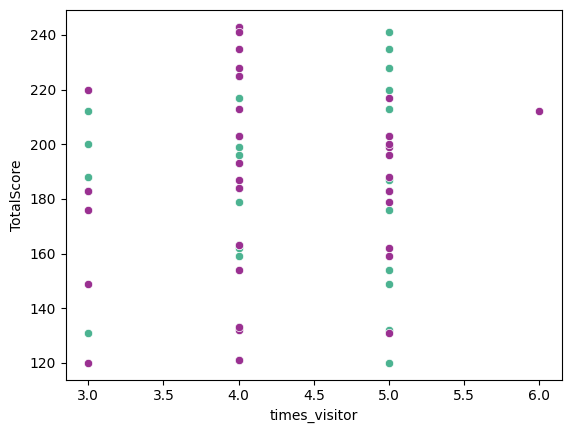

In [ ]:
ax = sns.scatterplot(data=team_resume, x="times_visitor", y='TotalScore', color="#4CB391")
sns.scatterplot(data=team_resume, x="times_home", y='TotalScore', color="#9A3091", ax=ax)

<Axes: xlabel='gameDate'>

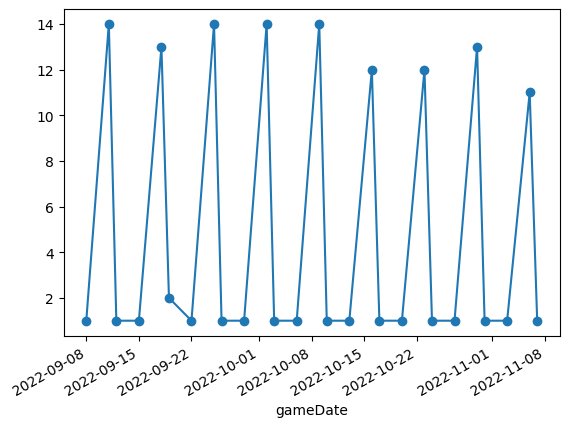

In [ ]:
games_df.groupby("gameDate").count().gameId.plot(marker='o')

### Players

In [ ]:
players_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1697 entries, 0 to 1696
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   nflId        1697 non-null   int64 
 1   height       1697 non-null   object
 2   weight       1697 non-null   int64 
 3   birthDate    1210 non-null   object
 4   collegeName  1697 non-null   object
 5   position     1697 non-null   object
 6   displayName  1697 non-null   object
dtypes: int64(2), object(5)
memory usage: 92.9+ KB


In [ ]:
players_df.height = players_df.height.str.replace("-", ".").astype(float)

In [ ]:
players_df.position.value_counts()

,count
position,
WR,224
CB,189
OLB,135
DE,131
RB,126
TE,123
DT,121
T,117
G,107


<Axes: xlabel='height', ylabel='Count'>

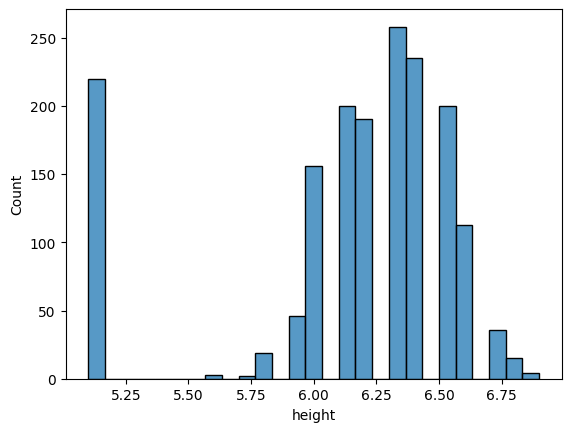

In [ ]:
sns.histplot(players_df.height)

<Axes: xlabel='weight', ylabel='Count'>

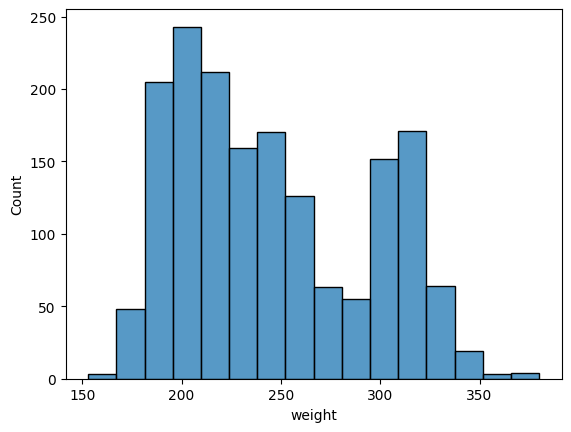

In [ ]:
sns.histplot(players_df.weight)

### Plays

In [ ]:
play_df.columns

Index(['gameId', 'playId', 'playDescription', 'quarter', 'down', 'yardsToGo',
       'possessionTeam', 'defensiveTeam', 'yardlineSide', 'yardlineNumber',
       'gameClock', 'preSnapHomeScore', 'preSnapVisitorScore',
       'playNullifiedByPenalty', 'absoluteYardlineNumber',
       'preSnapHomeTeamWinProbability', 'preSnapVisitorTeamWinProbability',
       'expectedPoints', 'offenseFormation', 'receiverAlignment',
       'playClockAtSnap', 'passResult', 'passLength', 'targetX', 'targetY',
       'playAction', 'dropbackType', 'dropbackDistance', 'passLocationType',
       'timeToThrow', 'timeInTackleBox', 'timeToSack', 'passTippedAtLine',
       'unblockedPressure', 'qbSpike', 'qbKneel', 'qbSneak',
       'rushLocationType', 'penaltyYards', 'prePenaltyYardsGained',
       'yardsGained', 'homeTeamWinProbabilityAdded',
       'visitorTeamWinProbilityAdded', 'expectedPointsAdded', 'isDropback',
       'pff_runConceptPrimary', 'pff_runConceptSecondary', 'pff_runPassOption',
       'pff_pass

In [ ]:
play_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16124 entries, 0 to 16123
Data columns (total 50 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   gameId                            16124 non-null  int64  
 1   playId                            16124 non-null  int64  
 2   playDescription                   16124 non-null  object 
 3   quarter                           16124 non-null  int64  
 4   down                              16124 non-null  int64  
 5   yardsToGo                         16124 non-null  int64  
 6   possessionTeam                    16124 non-null  object 
 7   defensiveTeam                     16124 non-null  object 
 8   yardlineSide                      15900 non-null  object 
 9   yardlineNumber                    16124 non-null  int64  
 10  gameClock                         16124 non-null  object 
 11  preSnapHomeScore                  16124 non-null  int64  
 12  preS

In [ ]:
#play_df[play_df.gameId==game_id].sort_values("playId")

### Players Play

In [ ]:
players_play_df.columns

Index(['gameId', 'playId', 'nflId', 'teamAbbr', 'hadRushAttempt',
       'rushingYards', 'hadDropback', 'passingYards', 'sackYardsAsOffense',
       'hadPassReception', 'receivingYards', 'wasTargettedReceiver',
       'yardageGainedAfterTheCatch', 'fumbles', 'fumbleLost',
       'fumbleOutOfBounds', 'assistedTackle', 'forcedFumbleAsDefense',
       'halfSackYardsAsDefense', 'passDefensed', 'quarterbackHit',
       'sackYardsAsDefense', 'safetyAsDefense', 'soloTackle', 'tackleAssist',
       'tackleForALoss', 'tackleForALossYardage', 'hadInterception',
       'interceptionYards', 'fumbleRecoveries', 'fumbleRecoveryYards',
       'penaltyYards', 'penaltyNames', 'wasInitialPassRusher',
       'causedPressure', 'timeToPressureAsPassRusher',
       'getOffTimeAsPassRusher', 'inMotionAtBallSnap', 'shiftSinceLineset',
       'motionSinceLineset', 'wasRunningRoute', 'routeRan',
       'blockedPlayerNFLId1', 'blockedPlayerNFLId2', 'blockedPlayerNFLId3',
       'pressureAllowedAsBlocker', 'timeT

### Tracking

In [ ]:
def draw_graph(G, pos, color=None):
    plt.figure()
    default_axes = plt.axes(frameon=True)
    edge_labels = nx.get_edge_attributes(G, "weight")
    for key,value in pos.items():
        pos[key] = np.array([value[0], value[1]+0.12])
    #nx.draw_networkx_edge_labels(G, pos = pos, )
    print(edge_labels.values())
    edges = G.edges()
    weights = [G[u][v]['weight'] for u,v in edges]
    nx.draw(G, pos=pos, width=weights, node_color=color)

def get_inverse_distance_graph(team, positions=False):
  weights = ss.distance_matrix(team[['x', 'y']], team[['x', 'y']])
  v = 1/weights**2
  v[v==np.inf] = 0
  G = nx.from_numpy_array(v)
  if positions:
    pos = team[['x', 'y']].reset_index(drop=True)
    pos['xy'] = pos.apply(lambda x: np.array([x.x, x.y]), axis=1)
    p = pos['xy'].to_dict()
    return G, p
  return G

In [ ]:
tracking_df.frameId.value_counts()

,count
frameId,
1,44896
10,44896
2,44896
17,44896
16,44896
...,...
616,23
615,23
614,23


<Axes: ylabel='gameId'>

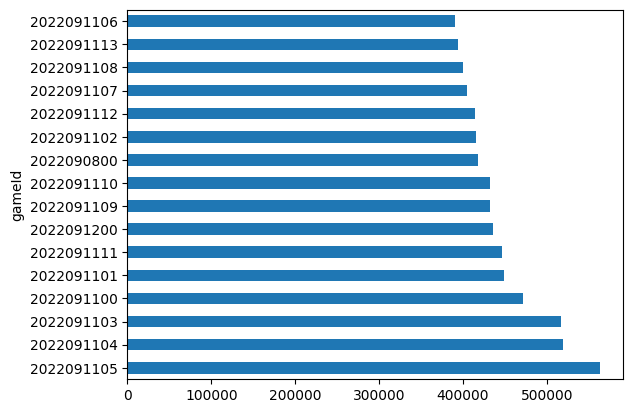

In [ ]:
tracking_df.gameId.value_counts().plot(kind='barh')

2022091104


,count
frameType,
BEFORE_SNAP,136
SNAP,136
AFTER_SNAP,136


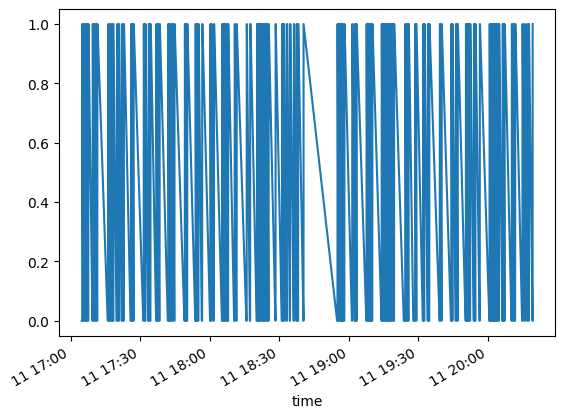

In [ ]:
game_id = tracking_df.gameId.value_counts().sample(1).index[0]
print(game_id)
specific_game = tracking_df[tracking_df.gameId == game_id]
specific_game.time = pd.to_datetime(specific_game.time, format='ISO8601')
event_dict = {'BEFORE_SNAP':0, 'AFTER_SNAP': 1, 'SNAP': 0.4}
snaps = specific_game.groupby("time").agg({"frameType": "first"})
snaps.frameType.apply(lambda x: event_dict[x]).plot()
a = snaps.frameType
reduced_snaps = a.loc[a.shift(-1) != a]
reduced_snaps.value_counts()

In [ ]:
frames_in_play = specific_game.groupby("playId").agg({"frameId": "count"})//23

<Axes: ylabel='Frequency'>

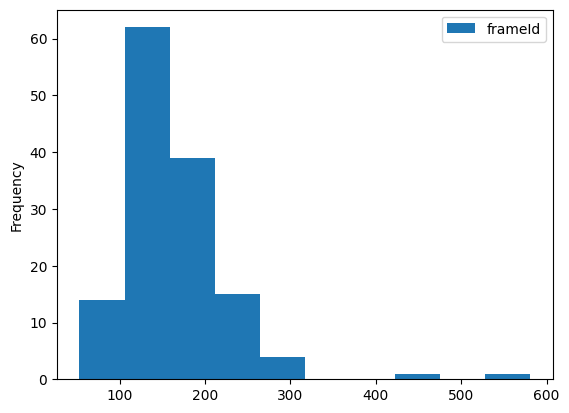

In [ ]:
frames_in_play.plot(kind='hist')

<Axes: ylabel='Frequency'>

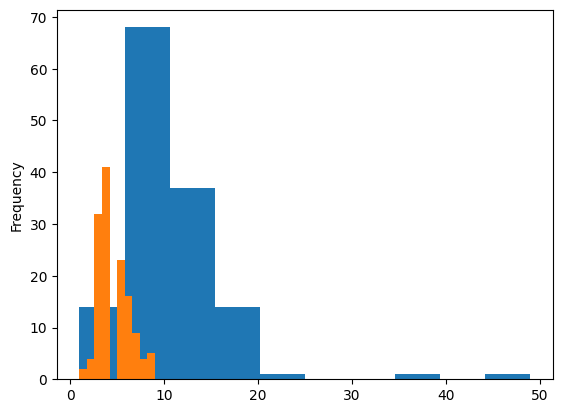

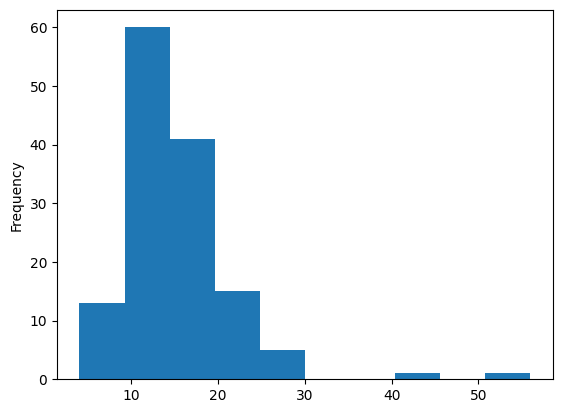

In [ ]:
specific_game_snap_actions = specific_game.groupby(["playId", "frameType"]).agg(
    time_min=("time", "min"),
    time_max=("time", 'max'),
    event_set = ("event", lambda x: set(x.dropna()))
).sort_values("time_min").reset_index()

specific_game_snap_actions["duration"] = (specific_game_snap_actions['time_max'] - specific_game_snap_actions['time_min']).dt.seconds
specific_game_snap_actions[specific_game_snap_actions.frameType == "BEFORE_SNAP"].duration.plot(kind='hist')
specific_game_snap_actions[specific_game_snap_actions.frameType == "AFTER_SNAP"].duration.plot(kind='hist')

play_actions = specific_game_snap_actions[specific_game_snap_actions.frameType!='SNAP'].groupby("playId").agg(
    {"duration": "sum", 'event_set': lambda x: {'before': x.iloc[0], 'after':x.iloc[1]}}
    )
plt.figure()
play_actions.duration.plot(kind='hist')

<Axes: xlabel='duration', ylabel='frameId'>

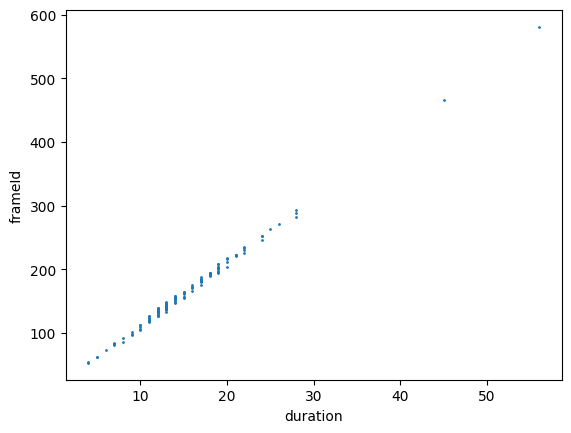

In [ ]:
pd.concat([play_actions, frames_in_play], axis=1).plot(kind='scatter', x='duration', y='frameId', s=1)

In [ ]:
#tracking_df.playId.value_counts()

Text(0.5, 1.0, 'Distribution of frames per play, in all games')

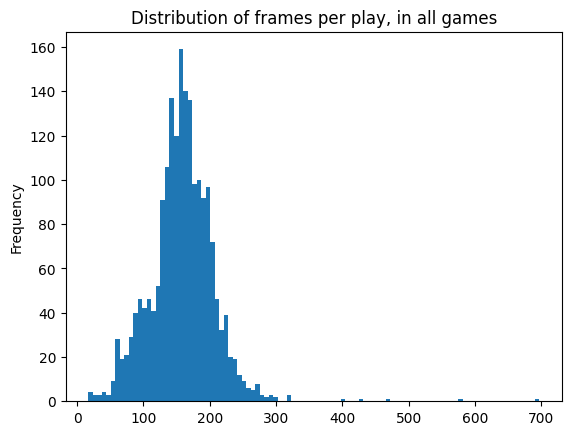

In [ ]:
(tracking_df.groupby("gameId").playId.value_counts()/23).plot(kind='hist', bins=100)
plt.title('Distribution of frames per play, in all games')

In [ ]:
tracking_df[tracking_df.frameType=='BEFORE_SNAP'].event.value_counts()

,count
event,
line_set,44206
huddle_break_offense,34477
man_in_motion,15548
shift,5888
timeout_away,23
huddle_start_offense,23


In [ ]:
tracking_df[tracking_df.frameType=='AFTER_SNAP'].event.value_counts()

,count
event,
first_contact,28865
tackle,27715
pass_forward,24794
pass_arrived,18791
handoff,15341
pass_outcome_caught,15249
play_action,8188
pass_outcome_incomplete,8142
out_of_bounds,4968


In [ ]:
play_id= tracking_df[tracking_df.gameId==game_id].playId.sample(1).iloc[0]
frame_game_play = tracking_df[(tracking_df.frameId==145) & (tracking_df.gameId==game_id) & (tracking_df.playId==play_id)]

In [ ]:
frame_game_play.head()

,gameId,playId,nflId,displayName,frameId,frameType,time,jerseyNumber,club,playDirection,x,y,s,a,dis,o,dir,event
4670317,2022091104,3059,38542.0,Fletcher Cox,145,AFTER_SNAP,2022-09-11 19:19:36.5,91.0,PHI,right,101.68,29.18,1.82,0.35,0.18,317.43,68.80,pass_outcome_caught
4670473,2022091104,3059,39984.0,Darius Slay,145,AFTER_SNAP,2022-09-11 19:19:36.5,2.0,PHI,right,111.88,14.91,3.68,0.74,0.37,352.91,4.71,pass_outcome_caught
4670629,2022091104,3059,43290.0,Jared Goff,145,AFTER_SNAP,2022-09-11 19:19:36.5,16.0,DET,right,97.69,28.79,0.94,0.45,0.09,358.78,238.26,pass_outcome_caught
4670785,2022091104,3059,43305.0,Taylor Decker,145,AFTER_SNAP,2022-09-11 19:19:36.5,68.0,DET,right,96.29,31.03,0.31,0.40,0.03,68.35,317.32,pass_outcome_caught
4670941,2022091104,3059,43351.0,James Bradberry,145,AFTER_SNAP,2022-09-11 19:19:36.5,24.0,PHI,right,114.16,34.83,3.17,3.49,0.34,27.55,97.62,pass_outcome_caught


In [ ]:
clubs = frame_game_play.club.value_counts() > 1
distinct_clubs = clubs[clubs].index.to_list()

both_teams = frame_game_play[frame_game_play.club.isin(distinct_clubs)]
team1 = both_teams[both_teams.club==distinct_clubs[0]]
team2 = both_teams[both_teams.club==distinct_clubs[1]]


In [ ]:
g1, pos1 = get_inverse_distance_graph(team1, positions=True)
g2, pos2 = get_inverse_distance_graph(team2, positions=True)

#draw_graph(g1, pos=pos1, color='blue')
#draw_graph(g2, pos=pos2, color='orange')

In [ ]:
g, pos = get_inverse_distance_graph(both_teams, positions=True)
#draw_graph(g, pos=pos)

In [ ]:
#bb = nx.betweenness_centrality(g)
#nx.set_node_attributes(g·#, bb, "betweenness")
#G.nodes[1]["betweenness"]

centrality_g2 = pd.DataFrame()
centrality_g2['betweenness_centrality'] = nx.betweenness_centrality(g2, weight='weight')
#centrality_g2['eigenvector_centrality'] = nx.eigenvector_centrality(g2, weight='weight')
centrality_g2['closeness_centrality'] = nx.closeness_centrality(g2, distance='weight')
#centrality_g2['katz_centrality'] = nx.katz_centrality(g2, weight='weight')
centrality_g2['current_flow_closeness_centrality'] = nx.current_flow_closeness_centrality(g2, weight='weight')
centrality_g2['harmonic_centrality'] = nx.harmonic_centrality(g2, distance='weight')
centrality_g2['team'] = 'g2'

In [ ]:
centrality_g1 = pd.DataFrame()
centrality_g1['betweenness_centrality'] = nx.betweenness_centrality(g1, weight='weight')
#centrality_g1['eigenvector_centrality'] = nx.eigenvector_centrality(g1, weight='weight')
centrality_g1['closeness_centrality'] = nx.closeness_centrality(g1, distance='weight')
#centrality_g1['katz_centrality'] = nx.katz_centrality(g1, weight='weight')
centrality_g1['current_flow_closeness_centrality'] = nx.current_flow_closeness_centrality(g1, weight='weight')
centrality_g1['harmonic_centrality'] = nx.harmonic_centrality(g1, distance='weight')
centrality_g1['team'] = 'g1'


centrality_g = pd.DataFrame()
centrality_g['betweenness_centrality'] = nx.betweenness_centrality(g, weight='weight')
#centrality_g['eigenvector_centrality'] = nx.eigenvector_centrality(g, weight='weight')
centrality_g['closeness_centrality'] = nx.closeness_centrality(g, distance='weight')
#centrality_g['katz_centrality'] = nx.katz_centrality(g, weight='weight')
centrality_g['current_flow_closeness_centrality'] = nx.current_flow_closeness_centrality(g, weight='weight')
centrality_g['harmonic_centrality'] = nx.harmonic_centrality(g, distance='weight')
centrality_g['team'] = 'both'

In [ ]:
centrality = pd.concat([centrality_g1, centrality_g2, centrality_g], axis=0)

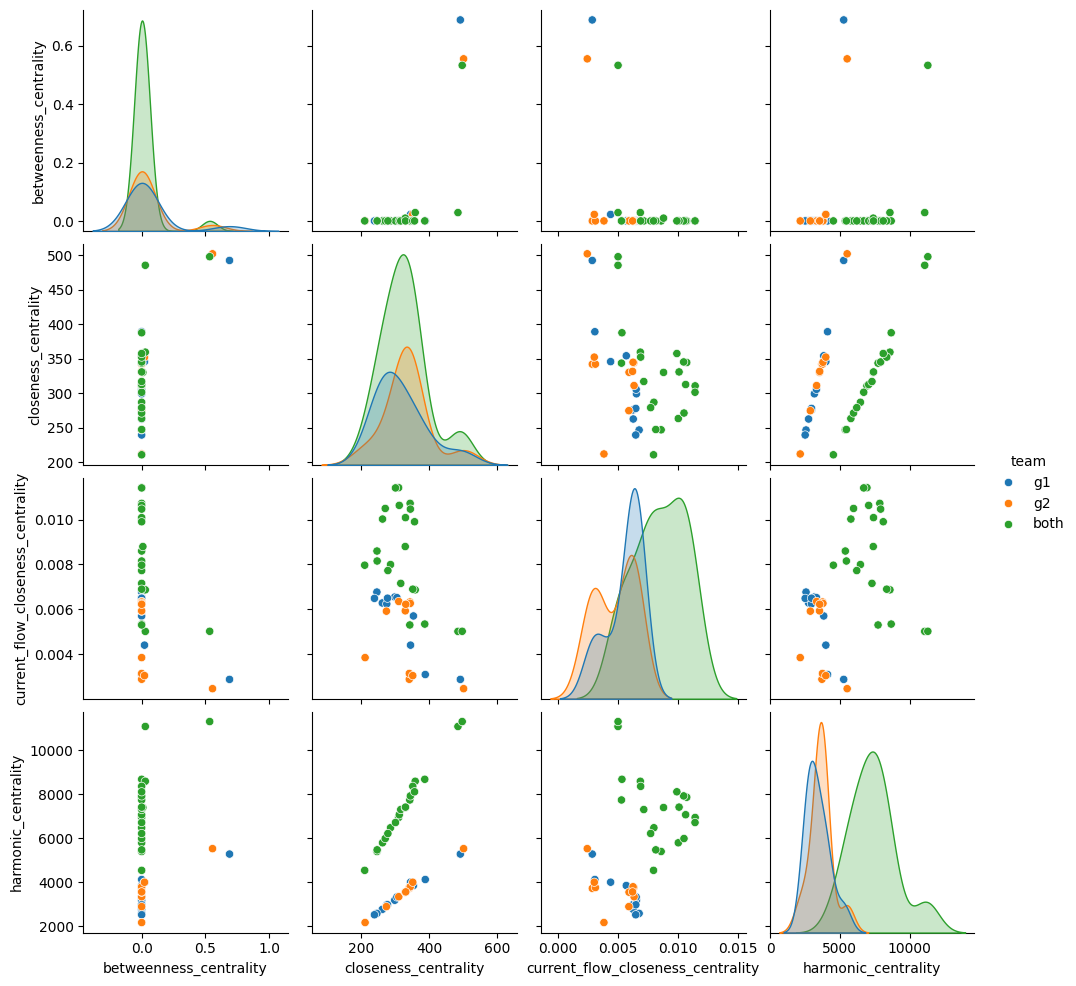

In [ ]:
sns.pairplot(centrality, hue='team')

In [ ]:
game_play = tracking_df[(tracking_df.gameId==game_id) & (tracking_df.playId==play_id)]

In [ ]:
pd.set_option('display.max_rows', 500)
#game_play[['displayName', 'event', 'frameId']].dropna()#.frameId.value_counts()


In [ ]:
game_play[game_play.frameId==140].time.unique()

array(['2022-09-11 19:19:36'], dtype=object)

In [ ]:
# unidad de analisis: frameId de un juego en especifico.
#game_play[game_play.frameId==145]

# Visualization Utils

In [ ]:
def plot_field():
  stadium_limit_dimension_y =  (0, 53.3333333)
  stadium_limit_dimension_x = (0, 120)
  color__green = "#586d3d"
  color__white = "#DADADA"
  color__brown = "#663831"
  color__yellow = "#cbb67c"
  text_position = 5
  portery_yards = 6.166667
  numbers = {20:'1 0', 30:'2 0', 40:'3 0', 50:'4 0', 60:'5 0', 70:'4 0', 80:'3 0', 90:'2 0', 100:'1 0'}


  fig, ax = plt.subplots(figsize=(15,5))
  plt.xlim(stadium_limit_dimension_x)
  plt.ylim(stadium_limit_dimension_y)
  plt.vlines(
      [i for i in range(0, max(stadium_limit_dimension_x), 10)],
      min(stadium_limit_dimension_y),
      max(stadium_limit_dimension_y),
      color=color__white,
      alpha=0.5
  )

  plt.vlines(
      [i for i in range(10, max(stadium_limit_dimension_x)-10, 5)],
      min(stadium_limit_dimension_y),
      max(stadium_limit_dimension_y),
      color=color__white,
      alpha=0.3
  )

  vlines2 = [i for i in range(10, max(stadium_limit_dimension_x)-10+1, 1)]
  vlines2_size=1
  plt.vlines(
      vlines2,
      min(stadium_limit_dimension_y),
      min(stadium_limit_dimension_y) + vlines2_size,
      color=color__white,
      alpha=0.3
  )
  plt.vlines(
      vlines2,
      max(stadium_limit_dimension_y),
      max(stadium_limit_dimension_y) - vlines2_size,
      color=color__white,
      alpha=0.5
  )

  vlines3_size = 0.5
  medium_vlines_pos = (min(stadium_limit_dimension_y) + max(stadium_limit_dimension_y))/2 + portery_yards/2
  medium_vlines_neg = (min(stadium_limit_dimension_y) + max(stadium_limit_dimension_y))/2 - portery_yards/2
  plt.vlines(
      vlines2,
      medium_vlines_pos + vlines3_size,
      medium_vlines_pos - vlines3_size,
      color=color__white,
      alpha=0.3
  )
  plt.vlines(
      vlines2,
      medium_vlines_neg + vlines3_size,
      medium_vlines_neg - vlines3_size,
      color=color__white,
      alpha=0.3
  )
  for p, n in numbers.items():
    plt.text(p, min(stadium_limit_dimension_y) + text_position, n, horizontalalignment='center', verticalalignment='center', color=color__white, rotation=0)
    plt.text(p, max(stadium_limit_dimension_y) - text_position, n, horizontalalignment='center', verticalalignment='center', color=color__white, rotation=180)

  triangle_pos = [(i + (i-5))/2 for i in range(20, max(stadium_limit_dimension_x)//2-10+1, 10)]
  plt.scatter(triangle_pos, [min(stadium_limit_dimension_y) + text_position]*len(triangle_pos), marker='<', s=10, color=color__white)
  plt.scatter(triangle_pos, [max(stadium_limit_dimension_y) - text_position]*len(triangle_pos), marker='<', s=10, color=color__white)

  triangle_pos2 = [(i + (i+5))/2 for i in range(70, max(stadium_limit_dimension_x)-10, 10)]
  plt.scatter(triangle_pos2, [min(stadium_limit_dimension_y) + text_position]*len(triangle_pos2), marker='>', s=10, color=color__white)
  plt.scatter(triangle_pos2, [max(stadium_limit_dimension_y) - text_position]*len(triangle_pos2), marker='>', s=10, color=color__white)
  ax.set_facecolor(color__green)
  plt.xticks([])
  plt.yticks([])
  return fig, ax

<Axes: xlabel='x', ylabel='y'>

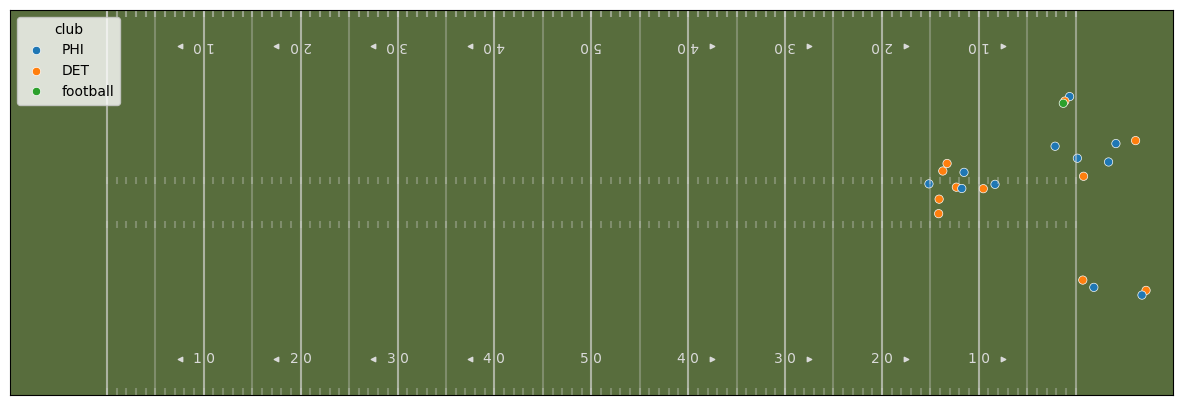

In [ ]:
fig, ax = plot_field()
sns.scatterplot(data=frame_game_play, x="x", y="y", hue="club", ax=ax)

# **Data** Generation

In [ ]:
# Contexto de la jugada al momento del play
#play_df[(play_df.gameId==2022091104) & (play_df.playId==1768)]

In [ ]:
# Que pasó al acabar la jugada por cada jugador.  #NOTA VERIFICAR SI ESTA INFORMACION SIRVE PARA PREDECIR
#players_play_df[(players_play_df.gameId==2022091104) & (players_play_df.playId==1768)]

In [ ]:
analysis_unit = game_play[game_play.frameId==145]

# We need analysis unit features, in a vector, not a matrix.

# Description of horizontal momentum from team1
# Description of horizontal momentum from team2
# Aligment of horizontal momentum with play.

# Description of vertical momentum from team1
# Description of vertical momentum from team2

# Description of h momentum from both teams
# Description of v momentum from both teams

# Distance of team1 vs team2 centroid

#Description distance from team1 to the ball
#Description distance from team2 to the ball

# Graph description of ball node centrality to team1 Done
# Graph description of ball node centrality to team2 Done

# Graph embeddings of team1
# Graph embeddings of team2
# Graph embeddings of both teams and ball

# team1 dominance in space
# team2 dominance in space

# Description orientation to enemy from team1. done
# Description orientation to enemy from team2. done

# Voronoi Area from each player compare the areas of team1 vs team2.
#analysis_unit

In [ ]:
#import inspect
#lines = inspect.getsource(ss.distance_matrix)
#print(lines)


In [ ]:
def angle_matrix(x, y, p=2, threshold=1000000):
  x = np.asarray(x)
  y = np.asarray(y)
  x = x[:,np.newaxis,:]
  y = y[np.newaxis,:,:]
  x_y = y-x
  arctan_vals = np.arctan2(x_y[:,:,1], x_y[:,:,0])*180/np.pi
  arctan_vals[arctan_vals < 0] = arctan_vals[arctan_vals < 0] + 360
  return arctan_vals



In [ ]:
def get_velocity_matrix(analysis_unit, not_ball=True):
  analysis_unit = analysis_unit.copy()
  if not_ball:
    analysis_unit = get_analysis_unit_without_ball(analysis_unit)
  analysis_unit['vx'] = analysis_unit.s*np.cos(np.deg2rad(analysis_unit.dir))
  analysis_unit['vy'] = analysis_unit.s*np.sin(np.deg2rad(analysis_unit.dir))
  # Get distance matrix
  velocity_matrix = ss.distance_matrix(
      analysis_unit[['vx', 'vy']],
      analysis_unit[['vx', 'vy']])
  velocity_matrix = np.nan_to_num(velocity_matrix, nan=0)
  return velocity_matrix

def get_acceleration_matrix(analysis_unit, not_ball=True):
  analysis_unit = analysis_unit.copy()
  if not_ball:
    analysis_unit = get_analysis_unit_without_ball(analysis_unit)

  analysis_unit['ax'] = analysis_unit.a*np.cos(np.deg2rad(analysis_unit.dir))
  analysis_unit['ay'] = analysis_unit.a*np.sin(np.deg2rad(analysis_unit.dir))
  # Get distance matrix
  acceleration_matrix = ss.distance_matrix(
      analysis_unit[['ax', 'ay']],
      analysis_unit[['ax', 'ay']])
  acceleration_matrix = np.nan_to_num(acceleration_matrix, nan=0)

  return acceleration_matrix

def get_analysis_unit_without_ball(analysis_unit):
  analysis_unit_without_ball = analysis_unit[analysis_unit.club!='football']
  return analysis_unit_without_ball

def get_look_matrix(analysis_unit, not_ball=True):
  analysis_unit = analysis_unit.copy()
  if not_ball:
    analysis_unit = get_analysis_unit_without_ball(analysis_unit)
  # Get the analysis unit without the ball.

  # Get the angle matrix, depending in positions.
  angles_according_to_position = angle_matrix(
      analysis_unit[['x', 'y']],
      analysis_unit[['x', 'y']]
      )
  # Compare if positions are aligned to orientation or direction.
  angles_according_to_position_o = angles_according_to_position - np.asarray(analysis_unit.o)
  angles_according_to_position_dir = angles_according_to_position - np.asarray(analysis_unit.dir)
  # Normalize the direction with cosine
  # (if aligned then 1, if not then 0, and any values between that, also negative alignment is possible).
  look_o = np.cos(np.deg2rad(angles_according_to_position_o)) # Relevance depending in direction
  look_dir = np.cos(np.deg2rad(angles_according_to_position_dir))
  # Sum the contribution of both alingments, at 50%50.
  look = (look_o + look_dir)/2
  look = np.nan_to_num(look, nan=0)
  return look

def get_inverse_distance_matrix(analysis_unit, power=1, not_ball=True):
  analysis_unit = analysis_unit.copy()
  if not_ball:
    analysis_unit = get_analysis_unit_without_ball(analysis_unit)
  # Get distance matrix
  unit_distance_matrix = ss.distance_matrix(
      analysis_unit[['x', 'y']],
      analysis_unit[['x', 'y']])
  # Divide 1 over the values by a power
  inverse_distance_matrix = 1/unit_distance_matrix**(power)
  # Replace infinite with 0
  inverse_distance_matrix[inverse_distance_matrix==np.inf] = 0
  inverse_distance_matrix = np.nan_to_num(inverse_distance_matrix, nan=0)
  return inverse_distance_matrix

def get_mechanical_element_matrix_weighted_by_look(analysis_unit):
  velocity_matrix = get_velocity_matrix(analysis_unit)
  acceleration_matrix = get_acceleration_matrix(analysis_unit)
  inverse_distance_matrix = get_inverse_distance_matrix(analysis_unit)
  look = get_look_matrix(analysis_unit)

  velocity_matrix_weighted = velocity_matrix * look
  acceleration_matrix_weighted = acceleration_matrix * look
  inverse_distance_matrix_weighted = inverse_distance_matrix * look
  mechanical_element_matrix = (
      inverse_distance_matrix_weighted +
      1/10*velocity_matrix_weighted +
      1/100*acceleration_matrix_weighted
  )
  return mechanical_element_matrix

def get_inverse_distance_matrix_weighted_by_look(analysis_unit, not_ball=False):
  inverse_distance_matrix = get_inverse_distance_matrix(analysis_unit, not_ball=not_ball, power=1)
  look = get_look_matrix(analysis_unit, not_ball=not_ball)
  inverse_distance_matrix_weighted = inverse_distance_matrix*look
  return inverse_distance_matrix_weighted

def get_team_positions(analysis_unit):
  analysis_unit_without_ball = get_analysis_unit_without_ball(analysis_unit)
  pos = analysis_unit_without_ball[['x', 'y']].reset_index(drop=True)
  pos['xy'] = pos.apply(lambda x: np.array([x.x, x.y]), axis=1)
  pos = pos['xy'].to_dict()
  return pos

def get_team_graph(analysis_unit, not_ball=False):
  #matrix = get_mechanical_element_matrix_weighted_by_look(analysis_unit)
  matrix = get_inverse_distance_matrix_weighted_by_look(analysis_unit, not_ball=not_ball)
  G = nx.from_numpy_array(matrix)
  return G

def get_team_characteristics(analysis_unit):
  analysis_unit_without_ball = get_analysis_unit_without_ball(analysis_unit)
  analysis_unit_without_ball = analysis_unit_without_ball.reset_index(drop=True)
  desired_cols = ['displayName', 'jerseyNumber', 'club']
  characteristics_dict = {}
  for col in desired_cols:
    characteristics_dict[col] = analysis_unit_without_ball[col].to_dict()
  return characteristics_dict

def set_team_characteristics(analysis_unit, G):
  characteristics_dict = get_team_characteristics(analysis_unit)
  for col, char in characteristics_dict.items():
    nx.set_node_attributes(G, char, col)
  return G

In [ ]:
team_characteristics = get_team_characteristics(analysis_unit)
team_G = get_team_graph(analysis_unit)
team_G = set_team_characteristics(analysis_unit, team_G)
pos = get_team_positions(analysis_unit)

In [ ]:
def draw_graph2(G, pos, ax=None):
  colors=['tab:blue', 'tab:orange']
  color_dict = {}
  node_colors = []
  i=0
  for node, attr in team_G.nodes(data=True):
    club = attr['club']
    if club not in color_dict:
      color_dict[club] = colors[i]
      i+=1
    node_colors.append(color_dict[club])

  edges = team_G.edges()
  weights = [team_G[u][v]['weight'] for u,v in edges]
  ec = nx.draw_networkx_edges(team_G, pos, ax=ax, width=weights, alpha=0.5)
  nc = nx.draw_networkx_nodes(team_G, pos, ax=ax,node_color=node_colors, node_size=50, alpha=0.5)

In [ ]:
unit_distance_matrix_ball = ss.distance_matrix(analysis_unit[['x', 'y']], analysis_unit[['x', 'y']])
inverse_distance_matrix_ball = 1/unit_distance_matrix_ball
inverse_distance_matrix_ball[inverse_distance_matrix_ball==np.inf] = 0

G_ball = nx.from_numpy_array(inverse_distance_matrix_ball)
pos_ball = analysis_unit[['x', 'y']].reset_index(drop=True)
pos_ball['xy'] = pos_ball.apply(lambda coordinate: np.asarray([coordinate.x, coordinate.y]), axis=1)
pos_ball = pos_ball['xy'].to_dict()

In [ ]:
centrality_ball = pd.DataFrame()
centrality_ball['betweenness_centrality'] = nx.betweenness_centrality(G_ball, weight='weight')
#centrality_ball['eigenvector_centrality'] = nx.eigenvector_centrality(G_ball, weight='weight')
centrality_ball['closeness_centrality'] = nx.closeness_centrality(G_ball, distance='weight')
#centrality_ball['katz_centrality'] = nx.katz_centrality(G_ball, weight='weight')
centrality_ball['current_flow_closeness_centrality'] = nx.current_flow_closeness_centrality(G_ball, weight='weight')
centrality_ball['harmonic_centrality'] = nx.harmonic_centrality(G_ball, distance='weight')
#centrality_ball['laplacian_centrality'] = nx.laplacian_centrality(G_ball, weight='weight')
centrality_ball.loc[22]

,22
betweenness_centrality,0.000000
closeness_centrality,15.232438
current_flow_closeness_centrality,0.070548
harmonic_centrality,363.463381


In [ ]:
analysis_unit_with_player_info = analysis_unit.merge(players_df, on='nflId', how='left')[['nflId','club', 's', 'a', 'dir','event', 'weight', 'position', 'dis', 'o']]

In [ ]:
analysis_unit_with_player_info['action'] = analysis_unit_with_player_info.weight*analysis_unit_with_player_info.s*analysis_unit_with_player_info.dis
analysis_unit_with_player_info['ke'] = 1/2*analysis_unit_with_player_info.weight*analysis_unit_with_player_info.s**2
analysis_unit_with_player_info['fx'] = analysis_unit_with_player_info.weight*analysis_unit_with_player_info.a*np.cos(np.deg2rad(analysis_unit_with_player_info.dir))
analysis_unit_with_player_info['fy'] = analysis_unit_with_player_info.weight*analysis_unit_with_player_info.a*np.sin(np.deg2rad(analysis_unit_with_player_info.dir))
analysis_unit_with_player_info['f'] = np.sqrt(analysis_unit_with_player_info.fx**2 + analysis_unit_with_player_info.fy**2)
analysis_unit_with_player_info['work'] = analysis_unit_with_player_info.f*analysis_unit_with_player_info.dis
analysis_unit_with_player_info.groupby('club').agg({'ke': 'sum', 'f': 'sum', 'work': 'sum', 'action':'sum'})

,ke,f,work,action
club,,,,
DET,10709.37355,4463.93,1237.4193,2181.1838
PHI,13189.94405,4996.74,1663.8890,2667.2270
football,0.00000,0.00,0.0000,0.0000


In [ ]:
def get_rotation_matrix(direction):
    theta = np.radians(direction)
    rotation_matrix = np.array(
        [[np.cos(theta), -np.sin(theta)],
         [np.sin(theta), np.cos(theta)]]
    )
    return rotation_matrix

def get_scaling_matrix(speed):
    max_speed = 13  #Max speed proposed in paper over the tracking data
    influence_radius = 4  # Influence in yards of the player.
    s_rat = (speed/max_speed)**2
    sx = (influence_radius + influence_radius * s_rat) / 2
    sy = (influence_radius - influence_radius * s_rat) / 2
    scaling_matrix = np.array(
        [[sx, 0],
         [0, sy]]
    )
    return scaling_matrix

def get_cov_matrix(direction, speed):
    rotation_matrix = get_rotation_matrix(direction)
    scaling_matrix = get_scaling_matrix(speed)
    inverse_rotation_matrix = np.linalg.inv(rotation_matrix)
    return rotation_matrix @ scaling_matrix @ scaling_matrix @ inverse_rotation_matrix

def influence(player):
  mean = np.array([
      player.x + 1/2*player.s*np.cos(np.deg2rad(player.dir)),
      player.y + 1/2*player.s*np.sin(np.deg2rad(player.dir))
  ])
  cov_matrix = get_cov_matrix(player.dir, player.s)
  cov_matrix_det = np.linalg.det(cov_matrix)
  cov_matrix_inv = np.linalg.inv(cov_matrix)
  func = lambda positions: 1/np.sqrt(2*np.pi*cov_matrix_det)*np.exp((-1/2)*(positions-mean).T @ cov_matrix_inv @ (positions-mean))
  return func

In [ ]:
def get_team_influences_func(analysis_unit):
  team_influences = {}
  for i in range(analysis_unit.shape[0]-1):
    team_influences[f'player{i}'] = influence(analysis_unit.iloc[i])
  return team_influences

In [ ]:
def get_team_influence_mesh(analysis_unit):
  team_influences = get_team_influences_func(analysis_unit)
  mg = np.array(np.meshgrid(np.linspace(0, 120, 50), np.linspace(0, 53.3333, 50)))
  xx, yy = mg
  z = np.zeros_like(xx, dtype=np.float32)
  for i in range(xx.shape[0]):
      for j in range(xx.shape[1]):
        for player, func in team_influences.items():
          z[i, j] = z[i, j] + func(np.array([xx[i, j], yy[i, j]]))
  return z

#def get_team_influence_individual(analysis_unit):
#  team_influences = get_team_influences_func(analysis_unit)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors
from colour import Color
norm = matplotlib.colors.Normalize(0,1)
c1 = Color("#586d3d")
nb_colors = 20
colors = list(c1.range_to(Color("#ff0000"), nb_colors))
colors_cmap = [[norm(i/nb_colors), f'{c}'] for i, c in enumerate(colors)] + [[norm(1), f'red']]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors_cmap)

In [ ]:
mg = np.array(np.meshgrid(np.linspace(0, 120, 50), np.linspace(0, 53.3333, 50)))
xx, yy = mg

In [ ]:
#fig, ax = plot_field()
#ax.contourf(xx, yy, z, cmap=cmap)
#draw_graph2(team_G, pos, ax=ax)
#sns.scatterplot(data=frame_game_play, x="x", y="y", hue="club", ax=ax)

In [ ]:
all_analysis_unit = game_play

In [ ]:
all_team_info = pd.DataFrame()
all_team_info['all_team_graphs'] = all_analysis_unit.groupby('frameId').apply(lambda x: set_team_characteristics(x, get_team_graph(x)))
all_team_info['all_team_pos'] = all_analysis_unit.groupby('frameId').apply(get_team_positions)

In [ ]:
#all_team_info['all_team_influence'] = all_analysis_unit.groupby('frameId').apply(get_team_influence_mesh)

In [ ]:
#for ix, row in all_team_info.iterrows():
#  fig, ax = plot_field()
  #ax.contourf(xx, yy, row.all_team_influence, cmap=cmap)
#  draw_graph2(row.all_team_graphs, row.all_team_pos, ax=ax)
#  plt.savefig(f'figures/experiments_d2/test_{ix}.png')

In [ ]:
# from PIL import Image

# def create_gif(image_paths, output_gif_path, duration=50):
#   images = [Image.open(image_path) for image_path in image_paths]
#   images[0].save(
#     output_gif_path,
#     save_all=True,
#     append_images=images[1:],
#     duration=duration,
#     loop=0 # 0 means infinite loop
#   )

# image_paths = [os.path.join(BASE_PATH, 'figures/experiments_d2',p ) for p in os.listdir('figures/experiments_d2')]
# output_gif_path = "output3.gif"
# create_gif(image_paths, output_gif_path)


# Response variable

In [ ]:
SECONDS = 1
cols = ['gameId', 'playId', 'frameId', 'frameType', 'time', 'playDirection', 'event']
event_occurence = tracking_df.drop_duplicates(['gameId', 'playId','frameId'])[cols]
event_occurence = event_occurence.fillna('None')
event_occurence.time = pd.to_datetime(event_occurence.time, format='ISO8601')
event_occurence['current_time'] = event_occurence.time - pd.Timedelta(seconds=SECONDS)
event_occurence['future_event'] = event_occurence.event
future_event_occurence = event_occurence[['gameId', 'playId', 'frameId', 'current_time', 'future_event']]
event_occurence = event_occurence.drop(['current_time', 'future_event'], axis=1)
event_occurence = event_occurence.merge(
    future_event_occurence[['current_time', 'future_event', 'playId', 'gameId']],
    left_on=['time', 'playId', 'gameId'],
    right_on=['current_time', 'playId', 'gameId'],
    how='left'
)

In [ ]:
RANDOM_SEED = 42
relevant_event_occurence = event_occurence[event_occurence.future_event!='None'].dropna()
non_relevant_event_occurence = event_occurence[event_occurence.future_event=='None'].sample(random_state=RANDOM_SEED, n=relevant_event_occurence.shape[0])
sample_event_occurence = pd.concat([relevant_event_occurence, non_relevant_event_occurence])
reorgainzed_sample_event_occurence = sample_event_occurence.sample(frac=1, random_state=RANDOM_SEED)
reorgainzed_sample_event_occurence['game_play_frame_id'] = reorgainzed_sample_event_occurence.apply(lambda x: f'{x.gameId}_{x.playId}_{x.frameId}', axis=1)

In [ ]:
tracking_df['game_play_frame_id'] = tracking_df.gameId.astype('str') + '_' + tracking_df.playId.astype('str') + '_' + tracking_df.frameId.astype('str')

In [ ]:
reduced_tracking_df = tracking_df[tracking_df.game_play_frame_id.isin(reorgainzed_sample_event_occurence.game_play_frame_id)]
reduced_tracking_df['game_play'] = reduced_tracking_df.gameId.astype('str') + '_' + reduced_tracking_df.playId.astype('str')

In [ ]:
play_df['game_play'] = play_df.gameId.astype('str') + '_' + play_df.playId.astype('str')
reduced_play_df = play_df[play_df.game_play.isin(reduced_tracking_df['game_play'])]
reduced_play_df['team_deffinition'] = reduced_play_df.apply(lambda x: {x.possessionTeam: 1, x.defensiveTeam: 0}, axis=1)
reduced_play_df['gameClock_time'] = reduced_play_df.gameClock.str.split(':').apply(lambda x: int(x[0])*60 + int(x[1]))
reduced_play_df['preSnapScore_difference'] = reduced_play_df['preSnapHomeScore'] - reduced_play_df['preSnapVisitorScore']
reduced_play_df['receiverAlignment_0'] = reduced_play_df.receiverAlignment.fillna('0x0').str.split('x').apply(lambda x: x[0])
reduced_play_df['receiverAlignment_1'] = reduced_play_df.receiverAlignment.fillna('0x0').str.split('x').apply(lambda x: x[1])

reduced_play_columns = [
    'quarter',
    'down',
    'yardsToGo',
    'yardlineNumber',
    'absoluteYardlineNumber',
    'preSnapHomeTeamWinProbability',
    'preSnapVisitorTeamWinProbability',
    'gameClock_time',
    'receiverAlignment_0',
    'receiverAlignment_1',
    'game_play',
    'team_deffinition',
]

reduced_play_df = reduced_play_df[reduced_play_columns]

In [ ]:
# Incluir caracteristicas del equipo, como los tipos de jugadores, y a qué equipo pertenecen
graphs_reduced_tracking_df = reduced_tracking_df.groupby('game_play_frame_id').apply(lambda x: set_team_characteristics(x, get_team_graph(x)))

## Graph experiments

In [ ]:
## Graph experiments:
graphs_reduced_tracking_df_testing = graphs_reduced_tracking_df.sample(10)

In [ ]:
# lets do the analysis unit:
analysis_unit

,gameId,playId,nflId,displayName,frameId,frameType,time,jerseyNumber,club,playDirection,x,y,s,a,dis,o,dir,event
6893083,2022090800,1800,34452.0,Matthew Stafford,145,AFTER_SNAP,2022-09-09 01:35:02.3,9.0,LA,left,44.810000,29.300000,2.00,2.35,0.19,286.52,93.83,NaN
6893261,2022090800,1800,37075.0,Von Miller,145,AFTER_SNAP,2022-09-09 01:35:02.3,40.0,BUF,left,41.490000,34.750000,5.21,2.27,0.51,102.36,103.04,NaN
6893439,2022090800,1800,40107.0,Micah Hyde,145,AFTER_SNAP,2022-09-09 01:35:02.3,23.0,BUF,left,24.240000,37.060000,2.44,1.20,0.24,71.95,292.07,NaN
6893617,2022090800,1800,40166.0,Jordan Poyer,145,AFTER_SNAP,2022-09-09 01:35:02.3,21.0,BUF,left,24.240000,17.970000,2.34,1.45,0.23,84.12,248.16,NaN
6893795,2022090800,1800,41290.0,Allen Robinson,145,AFTER_SNAP,2022-09-09 01:35:02.3,1.0,LA,left,38.590000,44.400000,3.30,3.73,0.32,267.38,296.42,NaN
6893973,2022090800,1800,41341.0,DaQuan Jones,145,AFTER_SNAP,2022-09-09 01:35:02.3,92.0,BUF,left,40.190000,30.590000,3.26,1.22,0.33,71.31,89.74,NaN
6894151,2022090800,1800,42395.0,Jordan Phillips,145,AFTER_SNAP,2022-09-09 01:35:02.3,97.0,BUF,left,39.720000,27.430000,2.42,0.74,0.24,70.22,63.48,NaN
6894329,2022090800,1800,42400.0,Rob Havenstein,145,AFTER_SNAP,2022-09-09 01:35:02.3,79.0,LA,left,42.520000,33.240000,3.20,1.10,0.32,275.45,75.73,NaN
6894507,2022090800,1800,43399.0,Tyler Higbee,145,AFTER_SNAP,2022-09-09 01:35:02.3,89.0,LA,left,38.350000,8.750000,4.20,4.12,0.42,201.80,263.60,NaN
6894685,2022090800,1800,44881.0,Cooper Kupp,145,AFTER_SNAP,2022-09-09 01:35:02.3,10.0,LA,left,39.240000,15.800000,3.60,4.03,0.36,260.73,256.49,NaN


In [ ]:
import scipy.sparse as sparse

def compute_graph_embeddings_with_node_attributes(analysis_unit, theta_max=2.5, eval_points=10, order = 5, return_ball_graph_info=False):
  # Symmetrical graphs
  velocity_graph = nx.from_numpy_array(get_velocity_matrix(analysis_unit))
  acceleration_graph = nx.from_numpy_array(get_acceleration_matrix(analysis_unit))
  inverse_distance_graph = nx.from_numpy_array(get_inverse_distance_matrix(analysis_unit))
  symmetrical_graphs = [velocity_graph, acceleration_graph, inverse_distance_graph]
  # We are just computing clustering and current_flow_closeness centrality for symmetrical graphs.
  symmetrical_graphs_clustering = [nx.clustering(g, weight='weight') for g in symmetrical_graphs]
  symmetrical_graphs_current_flow_closeness_centrality = [nx.current_flow_closeness_centrality(g, weight='weight') for g in symmetrical_graphs]
  symmetrical_computes = (
      symmetrical_graphs_clustering +
      symmetrical_graphs_current_flow_closeness_centrality
  )
  symmetrical_characteristics = ['vg', 'ag', 'id']
  symmetrical_operators = ['clustering', 'current_flow_closeness_centrality']
  symmetrical_columns = [f'{characteristic}_{operator}' for operator in symmetrical_operators for characteristic in symmetrical_characteristics]

  # Assymetrical graphs
  look_graph = nx.from_numpy_array(get_look_matrix(analysis_unit))
  team_graph = get_team_graph(analysis_unit, not_ball=True)
  look_graph_with_ball = nx.from_numpy_array(get_look_matrix(analysis_unit, not_ball=False))
  team_graph_with_ball = get_team_graph(analysis_unit, not_ball=False)

  asymmetrical_graphs = [look_graph, look_graph_with_ball, team_graph, team_graph_with_ball]
  asymmetrical_graphs_clustering = [nx.clustering(g, weight='weight') for g in asymmetrical_graphs]
  asymmetrical_graphs_current_flow_closeness_centrality = [nx.current_flow_closeness_centrality(g, weight='weight') for g in asymmetrical_graphs]
  asymmetrical_graphs_laplacian_centrality = [nx.laplacian_centrality(g, weight='weight') for g in asymmetrical_graphs]

  asymmetrical_characteristics = ['lg', 'lg_ball', 'tg', 'tg_ball']
  asymmetrical_operators = ['clustering', 'current_flow_closeness_centrality', 'laplacian_centrality']
  asymmetrical_columns = [f'{characteristic}_{operator}' for operator in asymmetrical_operators for characteristic in asymmetrical_characteristics]

  asymmetrical_computes = (
      asymmetrical_graphs_clustering +
      asymmetrical_graphs_current_flow_closeness_centrality +
      asymmetrical_graphs_laplacian_centrality
  )

  all_computes = symmetrical_computes + asymmetrical_computes
  all_columns = symmetrical_columns + asymmetrical_columns

  node_attributes_from_graphs_df = pd.DataFrame(all_computes).T
  node_attributes_from_graphs_df.columns = all_columns

  ball_graph_info = node_attributes_from_graphs_df[node_attributes_from_graphs_df.vg_clustering.isna()].iloc[0].dropna().to_dict()
  node_attributes_from_graphs_df_noball = node_attributes_from_graphs_df.dropna()


  theta = np.linspace(0.01, theta_max, eval_points)
  node_info_theta = np.outer(node_attributes_from_graphs_df_noball.to_numpy(), theta)
  n_nodes = team_graph.number_of_nodes()
  node_info_theta_reshaped = node_info_theta.reshape(n_nodes, -1)
  wave_node_info = np.concatenate([np.cos(node_info_theta_reshaped), np.sin(node_info_theta_reshaped)], axis=1)

  abs_degree = np.array([team_graph.degree(i, weight='weight') for i in range(n_nodes)]).reshape(-1, 1)
  values = 1/abs_degree.reshape(1, -1)[0]
  shape = (n_nodes, n_nodes)
  index = np.arange(n_nodes)

  degree_inverse = sparse.coo_matrix((values, (index, index)), shape=shape)
  adjacency = get_inverse_distance_matrix_weighted_by_look(analysis_unit=analysis_unit, not_ball=True)
  inverse_dot_adjacency = degree_inverse.dot(adjacency)

  feature_blocks = []
  for _ in range(order):
    wave_node_info = inverse_dot_adjacency.dot(wave_node_info)
    feature_blocks.append(wave_node_info)
  feature_blocks = np.concatenate(feature_blocks, axis=1)
  row_feature_blocks =  np.mean(feature_blocks, axis=0)
  if return_ball_graph_info:
    return row_feature_blocks, ball_graph_info
  return row_feature_blocks

In [ ]:
compute_graph_embeddings_with_node_attributes(analysis_unit, return_ball_graph_info=True)

(array([0.53384955, 0.5297435 , 0.51804208, ..., 0.13900406, 0.155861  ,
        0.17160447]),
 {'lg_ball_clustering': -0.08608289970903718,
  'tg_ball_clustering': -0.022291329984903366,
  'lg_ball_current_flow_closeness_centrality': -0.04385011612632241,
  'tg_ball_current_flow_closeness_centrality': -0.02733499085307894,
  'lg_ball_laplacian_centrality': 0.04054900456614372,
  'tg_ball_laplacian_centrality': 0.05461639865787182})

In [ ]:
graph_embeddings_with_ball_info = reduced_tracking_df.groupby('game_play_frame_id').apply(lambda x: compute_graph_embeddings_with_node_attributes(x, return_ball_graph_info=True))

## Feature experiments

In [ ]:
reduced_tracking_w_player_info_df = reduced_tracking_df.merge(players_df, on='nflId', how='left')[
    ['nflId','x', 'y','club', 's', 'a', 'dir','event', 'weight', 'position', 'dis', 'o', 'game_play_frame_id', 'game_play']
]

In [ ]:
reduced_tracking_w_player_info_df['action'] = reduced_tracking_w_player_info_df.weight*reduced_tracking_w_player_info_df.s*reduced_tracking_w_player_info_df.dis
reduced_tracking_w_player_info_df['ke'] = 1/2*reduced_tracking_w_player_info_df.weight*reduced_tracking_w_player_info_df.s**2
reduced_tracking_w_player_info_df['fx'] = reduced_tracking_w_player_info_df.weight*reduced_tracking_w_player_info_df.a*np.cos(np.deg2rad(reduced_tracking_w_player_info_df.dir))
reduced_tracking_w_player_info_df['fy'] = reduced_tracking_w_player_info_df.weight*reduced_tracking_w_player_info_df.a*np.sin(np.deg2rad(reduced_tracking_w_player_info_df.dir))
reduced_tracking_w_player_info_df['f'] = np.sqrt(reduced_tracking_w_player_info_df.fx**2 + reduced_tracking_w_player_info_df.fy**2)
reduced_tracking_w_player_info_df['work'] = reduced_tracking_w_player_info_df.f*reduced_tracking_w_player_info_df.dis

general_reduced_tracking_w_player_info_df = reduced_tracking_w_player_info_df.groupby('game_play_frame_id').agg(
    {'dis':'sum', 'ke': 'sum', 'f': 'sum', 'fx': 'sum', 'fy': 'sum', 'work': 'sum', 'action':'sum', 'x': 'mean', 'y':'mean'}
)
team_reduced_tracking_w_player_info_df = reduced_tracking_w_player_info_df[reduced_tracking_w_player_info_df.club != 'football'].groupby(['game_play_frame_id', 'club']).agg(
    {'dis':'sum', 'ke': 'sum', 'f': 'sum', 'fx': 'sum', 'fy': 'sum', 'work': 'sum', 'action':'sum', 'x': 'mean', 'y':'mean', 'game_play': 'first'}
).reset_index().merge(reduced_play_df[['game_play', 'team_deffinition']], on='game_play', how='left')

team_reduced_tracking_w_player_info_df['team_deffinition'] = team_reduced_tracking_w_player_info_df.apply(
    lambda row: row.team_deffinition[row.club], axis=1
)

team_reduced_tracking_w_player_info_df_possesion = team_reduced_tracking_w_player_info_df[
    team_reduced_tracking_w_player_info_df.team_deffinition == 1
].drop(['club', 'game_play', 'team_deffinition'], axis=1).set_index('game_play_frame_id')
team_reduced_tracking_w_player_info_df_defensive = team_reduced_tracking_w_player_info_df[
    team_reduced_tracking_w_player_info_df.team_deffinition == 0
].drop(['club', 'game_play', 'team_deffinition'], axis=1).set_index('game_play_frame_id')

team_reduced_tracking_w_player_info_df_difference = (
    team_reduced_tracking_w_player_info_df_possesion -
    team_reduced_tracking_w_player_info_df_defensive
)

team_reduced_tracking_w_player_info_df_difference = team_reduced_tracking_w_player_info_df_difference.rename(
    columns={col: f'{col}__difference' for col in team_reduced_tracking_w_player_info_df_difference.columns}
)
general_reduced_tracking_w_player_info_df = general_reduced_tracking_w_player_info_df.rename(
    columns={col: f'{col}__general' for col in general_reduced_tracking_w_player_info_df.columns}
)

In [ ]:
# Football distance to general centroid
football_info_df = reduced_tracking_w_player_info_df[reduced_tracking_w_player_info_df.club == 'football'].set_index('game_play_frame_id')
football_info_df.drop(['nflId', 'dir', 'event', 'weight', 'position', 'o', 'action', 'ke', 'fx', 'fy', 'f', 'work', 'club'], axis=1, inplace=True)
football_info_df['distance_general'] = (general_reduced_tracking_w_player_info_df.x__general - football_info_df.x)**2 + (general_reduced_tracking_w_player_info_df.y__general - football_info_df.y)**2
football_info_df['distance_possesion_team'] = (football_info_df.x-team_reduced_tracking_w_player_info_df_possesion.x)**2 + (football_info_df.y-team_reduced_tracking_w_player_info_df_possesion.y)**2
football_info_df['distance_defensive_team'] = (football_info_df.x-team_reduced_tracking_w_player_info_df_defensive.x)**2 + (football_info_df.y-team_reduced_tracking_w_player_info_df_defensive.y)**2

In [ ]:
all_players_reduced_tracking_positions = reduced_tracking_w_player_info_df[reduced_tracking_w_player_info_df.club != 'football'].set_index('game_play_frame_id')[['x', 'y', 'position', 'game_play', 'club']]
all_players_reduced_tracking_positions['distance_to_football'] = list((football_info_df.x-all_players_reduced_tracking_positions.x)**2 + (football_info_df.y-all_players_reduced_tracking_positions.y)**2)
all_players_reduced_tracking_positions.reset_index(inplace=True)
all_players_reduced_tracking_positions = all_players_reduced_tracking_positions.merge(reduced_play_df[['game_play', 'team_deffinition']], on='game_play', how='left')
all_players_reduced_tracking_positions['team_deffinition'] = all_players_reduced_tracking_positions.apply(
    lambda row: row.team_deffinition[row.club], axis=1
)

min_distances_to_ball = all_players_reduced_tracking_positions.sort_values(
    ['game_play_frame_id', 'distance_to_football', 'team_deffinition']
).drop_duplicates(
    ['game_play_frame_id', 'team_deffinition'], keep='first'
)

In [ ]:
min_distances_to_ball_defensive = min_distances_to_ball[min_distances_to_ball.team_deffinition==0].set_index('game_play_frame_id')[['position', 'distance_to_football']]
min_distances_to_ball_possesion = min_distances_to_ball[min_distances_to_ball.team_deffinition==1].set_index('game_play_frame_id')[['position', 'distance_to_football']]

In [ ]:
min_distances_to_ball_defensive.rename(columns={col: f'min_{col}_defensive' for col in min_distances_to_ball_defensive.columns}, inplace=True)
min_distances_to_ball_possesion.rename(columns={col: f'min_{col}_possesion' for col in min_distances_to_ball_possesion.columns}, inplace=True)
football_info_df.rename(columns={col:f'football_{col}' for col in football_info_df.columns}, inplace=True)

In [ ]:
result_df_list = [
    team_reduced_tracking_w_player_info_df_difference,
    general_reduced_tracking_w_player_info_df,
    min_distances_to_ball_defensive,
    min_distances_to_ball_possesion,
    football_info_df
]

In [ ]:
all_reduced_tracking_w_mechanical_info_df = pd.concat(
    result_df_list,
    axis=1
)

In [ ]:
# Transform
# offenseFormation categorical
# categorical

In [ ]:
pd.set_option('display.max_columns', 60)

In [ ]:
import scipy.sparse as sparse

def compute_grahp_embeddings(g):
  n_nodes = g.number_of_nodes()
  #abs_log_degree = np.array([np.log(abs(g.degree(i, weight='weight'))) for i in range(n_nodes)]).reshape(-1, 1)
  abs_log_degree = np.array([g.degree(i, weight='weight') for i in range(n_nodes)]).reshape(-1, 1)
  clustering_coefficient = np.array([nx.clustering(g, node, weight='weight') for node in range(n_nodes)]).reshape(-1, 1)
  node_info = np.concatenate([abs_log_degree, clustering_coefficient], axis=1)
  theta_max = 2.5
  eval_points = 25
  order = 3
  theta = np.linspace(0.01, theta_max, eval_points)
  node_info_theta = np.outer(node_info, theta)
  node_info_theta_reshaped = node_info_theta.reshape(g.number_of_nodes(), -1)
  node_info_theta_reshaped

  wave_node_info = np.concatenate([np.cos(node_info_theta_reshaped), np.sin(node_info_theta_reshaped)], axis=1)

  # Create  degree inverse and adjacency  (1/degree, weighted)
  index = np.arange(n_nodes)
  values = 1/abs_log_degree.reshape(1, -1)[0]
  shape = (n_nodes, n_nodes)
  degree_inverse = sparse.coo_matrix((values, (index, index)), shape=shape)
  adjacency = nx.adjacency_matrix(g, weight='weight')
  inverse_dot_adjacency = degree_inverse.dot(adjacency)

  # Compute feature blocks:
  feature_blocks = []
  for _ in range(order):
    wave_node_info = inverse_dot_adjacency.dot(wave_node_info)
    feature_blocks.append(wave_node_info)
  feature_blocks = np.concatenate(feature_blocks, axis=1)
  feature_blocks =  np.mean(feature_blocks, axis=0)
  return feature_blocks

In [ ]:
final_df = all_reduced_tracking_w_mechanical_info_df
#final_df['graphs'] = graphs_reduced_tracking_df
final_df['future_event'] = reorgainzed_sample_event_occurence.set_index('game_play_frame_id').future_event
#final_df['graph_embeddings'] = final_df['graphs'].apply(compute_grahp_embeddings)

In [ ]:
final_df

,dis__difference,ke__difference,f__difference,fx__difference,fy__difference,work__difference,action__difference,x__difference,y__difference,dis__general,ke__general,f__general,fx__general,fy__general,work__general,action__general,x__general,y__general,min_position_defensive,min_distance_to_football_defensive,min_position_possesion,min_distance_to_football_possesion,football_x,football_y,football_s,football_a,football_dis,football_game_play,football_distance_general,football_distance_possesion_team,football_distance_defensive_team,future_event
game_play_frame_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022090800_1009_102,-0.10,-15.70250,-225.10,-29.484963,42.685791,-4.8551,-4.4317,-6.005455,-0.740000,0.23,16.76720,275.22,61.890302,-27.097171,5.2233,4.7917,47.753913,25.223913,OLB,0.192402,C,0.432502,46.380001,23.790001,0.00,0.00,0.01,2022090800_1009,3.943738,3.728343,23.199016,ball_snap
2022090800_1009_111,-0.16,-67.90265,-304.51,74.682466,-163.622068,-17.4548,-14.0288,-6.005455,-0.747273,0.22,70.66795,635.71,226.996147,276.256433,20.5430,14.6160,47.760000,25.233044,DT,0.491605,WR,0.176502,46.400002,23.780001,0.00,0.00,0.00,2022090800_1009,3.960929,3.811343,23.159003,None
2022090800_1009_116,-0.20,-281.70915,187.02,672.050548,3565.569407,-69.9075,-56.2147,-5.953636,-0.747273,1.33,765.12155,6768.72,2013.214815,-356.574642,347.2855,140.1807,47.684348,25.249130,DT,3.317201,C,0.000500,44.270000,23.450001,5.54,0.73,0.55,2022090800_1009,14.894636,2.623194,47.937843,handoff
2022090800_1009_126,0.55,3461.80280,1187.96,292.098254,2638.585545,613.4472,652.1461,-5.328182,-0.426364,3.97,10471.37630,9775.24,1066.483351,-2044.027082,1777.9792,2039.3589,47.650435,25.665217,CB,3.437301,T,7.314084,42.310001,22.549999,2.01,5.18,0.20,2022090800_1009,38.224814,17.784811,80.058390,None
2022090800_1009_129,0.76,4860.42905,-1475.24,-633.952917,3084.828816,299.4256,954.7029,-5.082727,-0.284545,4.21,12009.87445,12186.14,3116.238739,579.243034,2150.1030,2375.6101,47.752174,25.788696,OLB,0.370001,RB,0.125000,43.090000,22.129999,3.15,0.37,0.31,2022090800_1009,35.121924,19.004102,70.728223,first_contact
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022091200_983_294,0.65,4645.55780,-439.13,-1072.095340,-2661.089000,88.3215,960.8071,5.060909,0.111818,7.29,31352.40800,8741.39,6294.621196,-360.337651,2901.2017,6201.1665,90.219130,28.056087,OLB,0.279698,QB,0.070900,96.849998,25.660000,3.64,8.21,0.32,2022091200_983,49.709645,25.934246,95.541226,first_contact
2022091200_983_307,0.83,5875.14195,484.37,510.081765,647.627527,867.1001,1273.7274,2.728182,-0.252727,7.66,32377.59785,13281.57,5612.833798,-6029.094547,4116.4079,6590.8390,89.053913,30.931304,NT,1.906898,G,0.184501,92.110001,27.920000,4.08,4.61,0.43,2022091200_983,18.407624,12.483615,31.507963,tackle
2022091200_983_308,0.72,5285.54635,308.01,1389.629530,528.232648,671.5788,1120.6400,2.576364,-0.270000,7.40,30480.72395,13454.41,4446.191841,-6386.450418,4094.8632,6197.9702,88.940435,31.049130,OLB,0.122900,C,3.648994,91.730003,27.940001,3.62,4.52,0.38,2022091200_983,17.448381,12.357041,29.139530,None


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    final_df.drop(['future_event'], axis=1),
    #final_df.drop(['future_event', 'graphs'], axis=1),
    final_df['future_event'], test_size=0.2, random_state=RANDOM_SEED)

In [ ]:
#x_train_graph_embeddings = X_train['graph_embeddings'].apply(lambda x: list(x)).to_list()
#x_test_graph_embeddings = X_test['graph_embeddings'].apply(lambda x: list(x)).to_list()

In [ ]:
# import pca from sklearn
from sklearn.decomposition import PCA

In [ ]:
pca_model = PCA(n_components=100)
pca_model.fit(x_train_graph_embeddings)
real_n_components = (abs(np.gradient(np.log(pca_model.explained_variance_))) > 0.5).sum()
pca_model = PCA(n_components=real_n_components*2)
pca_model.fit(x_train_graph_embeddings)

PCA(n_components=22)

In [ ]:
#x_train_graph_embeddings2 = pca_model.transform(x_train_graph_embeddings)
#x_test_graph_embeddings2 = pca_model.transform(x_test_graph_embeddings)

#x_train_graph_embeddings2 = pd.DataFrame(x_train_graph_embeddings2, columns=[f'graph_embedding_{i}' for i in range(real_n_components*2)], index=X_train.index).map(np.log)
#x_test_graph_embeddings2 = pd.DataFrame(x_test_graph_embeddings2, columns=[f'graph_embedding_{i}' for i in range(real_n_components*2)], index=X_test.index).map(np.log)

In [ ]:
#x_train_graph_embeddings2.describe()
X_train

,dis__difference,ke__difference,f__difference,fx__difference,fy__difference,work__difference,action__difference,x__difference,y__difference,dis__general,ke__general,f__general,fx__general,fy__general,work__general,action__general,x__general,y__general,min_position_defensive,min_distance_to_football_defensive,min_position_possesion,min_distance_to_football_possesion,football_x,football_y,football_s,football_a,football_dis,football_game_play,football_distance_general,football_distance_possesion_team,football_distance_defensive_team
game_play_frame_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022091104_777_106,-0.02,17.00895,60.67,-283.949367,-43.701987,1.0219,1.6565,-6.131818,-0.690000,0.73,360.16365,1878.87,663.630829,1108.619706,63.0229,71.0707,41.288696,23.956522,DE,5.984096,WR,0.689299,40.790001,23.730000,0.00,0.00,0.01,2022091104_777,0.300009,6.486419,13.207032
2022091109_1968_62,-3.12,-18848.05160,-543.48,1024.346368,308.027717,-967.3838,-3758.1676,-6.389091,2.327273,6.13,24857.61420,6093.42,-4164.022788,2492.270128,1739.5754,4943.5986,81.121304,22.513478,SS,3.079397,G,6.990396,84.769997,2.710000,3.15,2.04,0.33,2022091109_1968,405.490706,527.304923,382.195994
2022091100_3355_145,-0.13,-31.00705,-603.21,-225.391175,-152.169580,-12.9696,-6.4248,6.525455,0.191818,0.17,31.03085,612.73,232.100472,145.415637,13.0648,6.4724,68.600000,25.998261,DE,0.219600,WR,7.062499,70.320000,23.590000,0.00,0.00,0.00,2022091100_3355,8.758119,8.975989,31.478000
2022091113_2283_143,0.26,1613.07975,372.18,-458.667440,173.309827,204.4446,308.7880,5.216364,0.724545,0.62,1658.31735,858.42,-694.221881,-71.261106,225.5862,320.4536,76.871304,26.544348,CB,0.001000,G,2.688202,77.580002,23.790001,0.00,0.00,0.00,2022091113_2283,8.088679,13.996080,17.553080
2022091102_3628_110,0.84,8735.39950,1576.92,-177.008965,-922.594918,825.5255,1712.8464,-5.337273,0.520909,6.17,22447.59100,8698.08,742.420349,116.431263,2462.1133,4484.4136,21.015652,28.933478,SS,8.490602,G,7.516795,13.370000,29.420000,1.57,3.41,0.17,2022091102_3628,58.692702,28.412380,114.265870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022091106_3399_106,0.33,4557.31425,866.57,1082.914054,1563.154625,166.9012,898.5046,-6.933636,-0.202727,1.75,5620.50965,7384.85,-291.671899,-937.057157,736.6828,1124.6990,76.248696,30.005652,NT,9.505602,QB,0.013000,74.889999,29.860001,0.00,0.00,0.00,2022091106_3399,1.867270,4.190193,23.949772
2022091113_3139_138,-0.12,-1.84330,-33.30,-30.044736,-19.191566,-3.6610,-3.3794,5.389091,0.371818,0.18,1.86430,37.50,27.001698,22.086375,3.7030,3.4214,82.343044,25.570870,CB,0.030599,C,1.375296,83.010002,23.820000,0.00,0.00,0.00,2022091113_3139,3.510379,8.054813,14.208976
2022091102_3783_87,-0.64,-555.73580,-1015.23,65.936683,211.356300,-117.3619,-127.5968,-7.010000,0.121818,0.82,562.50770,1183.09,-44.105532,-176.451542,119.3673,129.4774,39.520870,27.940435,DT,0.060500,C,2.423203,37.750000,29.889999,0.01,0.01,0.00,2022091102_3783,6.936781,6.644118,33.096811


In [ ]:
X_TRAIN = X_train.drop(['min_position_defensive', 'min_position_possesion'], axis=1)
X_TEST = X_test.drop(['min_position_defensive', 'min_position_possesion'], axis=1)

#X_TRAIN = pd.concat([X_train.drop('graph_embeddings', axis=1), x_train_graph_embeddings2], axis=1)
#X_TEST = pd.concat([X_test.drop('graph_embeddings', axis=1), x_test_graph_embeddings2], axis=1)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
models = {}
#models['LogisticRegression'] = LogisticRegression()
#models['SVC'] = SVC()
models['RandomForestClassifier'] = RandomForestClassifier()

#models['LogisticRegression'].fit(X, y_train)
#models['SVC'].fit(X, y_train)
models['RandomForestClassifier'].fit(X_TRAIN, y_train)

RandomForestClassifier()

In [ ]:
prediction = {}
for key in models.keys():
  prediction[key] = models[key].predict(X_TEST)

In [ ]:
for key in models.keys():
  print(f'Model: {key}')
  #print(f'Accuracy: {accuracy_score(y_test, prediction[key])}')
  #print(confusion_matrix(y_test, prediction[key]))
  print(classification_report(y_test, prediction[key]))

Model: RandomForestClassifier
                           precision    recall  f1-score   support

                     None       0.55      0.83      0.66      2353
                ball_snap       0.24      0.04      0.07       400
             dropped_pass       0.00      0.00      0.00         6
            first_contact       0.35      0.20      0.26       250
                   fumble       0.00      0.00      0.00        11
 fumble_defense_recovered       0.00      0.00      0.00         6
 fumble_offense_recovered       0.00      0.00      0.00         6
                  handoff       0.62      0.60      0.61       147
     huddle_break_offense       0.00      0.00      0.00         1
                  lateral       0.00      0.00      0.00         3
                 line_set       0.46      0.17      0.25       343
            man_in_motion       0.00      0.00      0.00       144
            out_of_bounds       0.43      0.25      0.32        40
             pass_arrived      